# Lựa chọn đặc trưng theo mô hình (Model-based)

Notebook này dùng nhiều mô hình để đo mức quan trọng của đặc trưng và tạo bảng xếp hạng tổng hợp.

## 1. Import thư viện

In [14]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Setup paths
PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'research' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu

In [23]:
data_path = PROJECT_ROOT / 'data' / 'raw' / 'abalone.csv'

df = pd.read_csv(data_path, header=None)
df.columns = [
    "sex",
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
    "rings",
]

print("Shape:", df.shape)
df.head()

Shape: (4177, 9)


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Chia tập train, validation, test

In [16]:
X = df.drop(columns=["rings"])
y = df["rings"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Tập huấn luyện:", X_train.shape, y_train.shape)
print("Tập validation:", X_val.shape, y_val.shape)
print("Tập test:", X_test.shape, y_test.shape)

Tập huấn luyện: (2923, 8) (2923,)
Tập validation: (627, 8) (627,)
Tập test: (627, 8) (627,)


## 4. Tiền xử lý bằng Pipeline

In [17]:
numeric_columns = [
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
]

categorical_columns = ["sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_columns),
    ("cat", categorical_transformer, categorical_columns),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print("Số đặc trưng sau preprocessing:", len(feature_names))

Số đặc trưng sau preprocessing: 10


## 5. Huấn luyện các mô hình và lấy độ quan trọng

In [18]:
model_dict = {
    "random_forest": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "extra_trees": ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "ridge": Ridge(alpha=1.0),
}

metric_results = []
all_importances = []

for model_name, model in model_dict.items():
    model.fit(X_train_processed, y_train)
    val_predictions = model.predict(X_val_processed)

    mae = mean_absolute_error(y_val, val_predictions)
    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    r2 = r2_score(y_val, val_predictions)

    metric_results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    else:
        importance = np.abs(model.coef_)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance,
        "model": model_name,
    })
    all_importances.append(importance_df)

metric_df = pd.DataFrame(metric_results).sort_values(by="RMSE")
metric_df

,model,MAE,RMSE,R2
2,ridge,1.620732,2.224273,0.506883
0,random_forest,1.594844,2.269166,0.486777
1,extra_trees,1.611240,2.289981,0.477318


## 6. Tổng hợp xếp hạng đặc trưng

In [19]:
all_df = pd.concat(all_importances, ignore_index=True)

# Chuẩn hóa độ quan trọng theo từng mô hình để so sánh công bằng
all_df["normalized_importance"] = all_df.groupby("model")["importance"].transform(
    lambda x: x / (x.max() + 1e-12)
)

summary_df = (
    all_df.groupby("feature")["normalized_importance"]
    .mean()
    .reset_index()
    .rename(columns={"normalized_importance": "average_score"})
    .sort_values(by="average_score", ascending=False)
)

summary_df.head(15)

,feature,average_score
6,num__shell_weight,0.753377
7,num__shucked_weight,0.620068
9,num__whole_weight,0.536496
3,num__diameter,0.251245
8,num__viscera_weight,0.240857
4,num__height,0.193210
5,num__length,0.166880
1,cat__sex_I,0.137561
2,cat__sex_M,0.042479
0,cat__sex_F,0.036070


## 7. Biểu đồ top đặc trưng

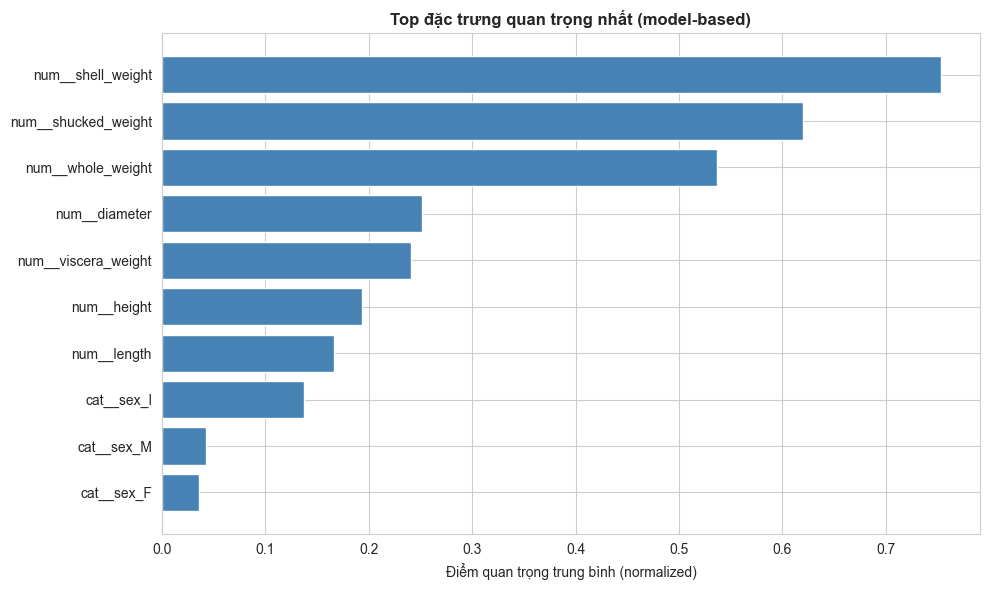

Saved figure: 03_feature_selection_model_based_top_features.png


In [20]:
top_n = 12
top_df = summary_df.head(top_n).sort_values(by="average_score")

plt.figure(figsize=(10, 6))
plt.barh(top_df["feature"], top_df["average_score"], color="steelblue")
plt.title("Top đặc trưng quan trọng nhất (model-based)", fontweight="bold")
plt.xlabel("Điểm quan trọng trung bình (normalized)")
plt.tight_layout()

figures_path = FIGURES_DIR
plt.savefig(figures_path / "03_feature_selection_model_based_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure: 03_feature_selection_model_based_top_features.png")

## 8. Đánh giá mô hình tốt nhất trên test

In [21]:
best_model = metric_df.iloc[0]["model"]
model = model_dict[best_model]

test_predictions = model.predict(X_test_processed)
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("Mô hình tốt nhất trên validation:", best_model)
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R2: {test_r2:.4f}")

Mô hình tốt nhất trên validation: ridge
Test MAE: 1.5451
Test RMSE: 2.1457
Test R2: 0.5515


## 9. Lưu kết quả

In [22]:
metrics_path = METRICS_DIR

metric_df.to_csv(metrics_path / "03_model_based_model_metrics.csv", index=False)
all_df.to_csv(metrics_path / "03_model_based_all_importance.csv", index=False)
summary_df.to_csv(metrics_path / "03_model_based_feature_ranking.csv", index=False)

summary = {
    "method": "model_based",
    "best_model": best_model,
    "test": {
        "MAE": test_mae,
        "RMSE": test_rmse,
        "R2": test_r2,
    },
    "top_10": summary_df.head(10).to_dict(orient="records"),
}

with open(metrics_path / "03_model_based_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved: 03_model_based_model_metrics.csv")
print("Saved: 03_model_based_all_importance.csv")
print("Saved: 03_model_based_feature_ranking.csv")
print("Saved: 03_model_based_summary.json")

Saved: 03_model_based_model_metrics.csv
Saved: 03_model_based_all_importance.csv
Saved: 03_model_based_feature_ranking.csv
Saved: 03_model_based_summary.json
